# 08 | Real CASALS RX waveform decomposition

This notebook fits a small sum of Gaussian-shaped waveform components to six selected real November 18 RX records. It retains the raw samples, uses the existing detector as initialization/overlay, and chooses component count by BIC. The fitted curves are **waveform-derived components**, not verified physical returns and not additional official geolocated points. The one official Refh-associated bin remains the raw RX maximum.

The final case is selected from Notebook 09 when its small handoff file exists. A strong isolated early transient is labeled unconfirmed; it does not become a window-reflection example without a recurring band.

## Inputs, scope and case selection

The four scene-context examples reuse the visually reviewed Notebook 06 pulses (probable labels remain probable); a low-SNR pulse demonstrates the fitting limit. One additional pulse is selected from the bounded Notebook 09 screen when available. If that handoff is absent, this notebook uses the previously selected broad/ambiguous real pulse as an independent fallback. Each pulse is read by its verified sweep/track grid identity; no full RX cube is loaded.

The single-Gaussian family is an intentionally simple morphology model. The detector configuration is reused when saved, but no production detector behavior is changed. Gaussian widths, amplitudes and centers describe the fitted waveform only.

In [1]:
from pathlib import Path
import json, sys
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

ROOT = Path.cwd()
if not (ROOT / "casals_l1b").is_dir():
    raise RuntimeError("Start Jupyter from the CASALS repository root.")
sys.path.insert(0, str(ROOT))
from research.nadir_window_reflection import mask_bins
from research.waveform_decomposition import estimate_baseline, fit_gaussian_components
from casals_l1b.peaks_cli import build_detector_config, default_config
from casals_l1b.waveform import (
    build_record_index_grid, detect_candidate_components_1d, infer_waveform_record_axis,
    preprocess_waveform, read_waveform_records,
)

H5_PATH = ROOT / "data/raw/casals_l1b/casals_l1b_20241118T171757_001_02.h5"
if not H5_PATH.is_file():
    raise FileNotFoundError(f"Missing real CASALS L1B input: {H5_PATH}")
OUTPUT_DIR = ROOT / "outputs/notebooks/08_waveform_decomposition" / H5_PATH.stem
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DPI = 190
MAX_COMPONENTS = 5
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold"})

source06 = ROOT / "outputs/notebooks/06_waveform_gallery" / H5_PATH.stem
source06_cases = source06 / "selected_waveform_cases.json"
source06_components = source06 / "selected_components.json"
source09_pulses = ROOT / "outputs/notebooks/09_nadir_window_reflection" / H5_PATH.stem / "window_reflection_selected_pulses.json"
print({"h5": str(H5_PATH.relative_to(ROOT)), "output": str(OUTPUT_DIR.relative_to(ROOT)),
       "notebook09_handoff_available": source09_pulses.is_file()})

{'h5': 'data\\raw\\casals_l1b\\casals_l1b_20241118T171757_001_02.h5', 'output': 'outputs\\notebooks\\08_waveform_decomposition\\casals_l1b_20241118T171757_001_02', 'notebook09_handoff_available': True}


## Bounded waveform reads and detector references

H5 background mean and standard deviation initialize each fit. The current detector is rerun with the saved configuration and its component bins are compared with Notebook 06 where cached markers exist. The fitting layer evaluates 1 to 5 Gaussian components only when a detected peak exceeds the background-noise gate. If the H5 Refh SNR is below 5, the exploratory fit is capped at K=1 to limit overfitting. A low-SNR record may therefore return K=0 rather than forcing a fit.


In [2]:
default_cases = [
    {"case": "A", "pulse_index": 2128614, "role": "probable tree canopy; multiple detector components"},
    {"case": "B", "pulse_index": 2085162, "role": "probable tree canopy; single dominant detector component"},
    {"case": "C", "pulse_index": 2827710, "role": "probable open field; single dominant component"},
    {"case": "D", "pulse_index": 3082120, "role": "probable road / mixed verge; single dominant component"},
    {"case": "E", "pulse_index": 1280439, "role": "low-SNR / ambiguous waveform"},
]
metadata06 = json.loads(source06_cases.read_text(encoding="utf-8")) if source06_cases.is_file() else {}
source_case_by_pulse = {int(row["pulse_index"]): row for row in metadata06.get("cases", [])}
component_cache = json.loads(source06_components.read_text(encoding="utf-8")) if source06_components.is_file() else {}
component_cache_by_pulse = {
    int(row["pulse_index"]): values
    for row, values in zip(metadata06.get("cases", []), component_cache.get("components", []))
}
if metadata06.get("detector_config"):
    detector_config = metadata06["detector_config"]
    detector_config_source = str(source06_cases.relative_to(ROOT))
else:
    detector_config = build_detector_config(default_config([H5_PATH], OUTPUT_DIR))
    detector_config_source = "current package default detector configuration"

if source09_pulses.is_file():
    handoff = json.loads(source09_pulses.read_text(encoding="utf-8"))
    screen_record = handoff.get("selected_pulses", [{}])[0]
    screen_case = screen_record.get("case", {})
    screen_pulse = int(screen_case["pulse_index"])
    screen_status = str(screen_record.get("status", "unconfirmed_screening_case"))
    screen_reason = str(screen_record.get("reason", ""))
else:
    # Independent real-H5 fallback already reviewed for broad/ambiguous morphology.
    screen_pulse = 1280230
    screen_status = "independent_gallery_fallback"
    screen_reason = "Notebook 09 handoff was absent; fallback is an existing real low-SNR broad waveform, not a ghost label."

selected = default_cases + [{"case": "F", "pulse_index": screen_pulse,
                             "role": "unconfirmed early-transient screen" if screen_status != "independent_gallery_fallback" else "independent broad/ambiguous fallback",
                             "screen_status": screen_status, "screen_reason": screen_reason}]
selected = [row for i, row in enumerate(selected) if row["pulse_index"] not in {item["pulse_index"] for item in selected[:i]}]
selected_pulses = np.asarray([int(row["pulse_index"]) for row in selected], dtype=np.int64)
if len(selected) > 6:
    raise RuntimeError("The gallery is limited to six cases.")

with h5py.File(H5_PATH, "r") as h5:
    index = build_record_index_grid(h5)
    if not index.complete_rectangular_grid or index.duplicate_sweep_track_cells:
        raise RuntimeError("The H5 sweep/track mapping is not a unique complete rectangle.")
    for row in selected:
        pulse = int(row["pulse_index"])
        sweep, track = int(index.sweep_num[pulse]), int(index.track_num[pulse])
        if int(index.record_index_grid[sweep, track]) != pulse:
            raise RuntimeError(f"Pulse identity mismatch for {pulse}.")
        row["sweep_num"], row["track_num"] = sweep, track
    rx_axis = infer_waveform_record_axis(h5["rx_waveform"], index.n_records)
    rx = read_waveform_records(h5["rx_waveform"], rx_axis, selected_pulses)
    scalar_names = ["bg_mean", "bg_std", "refh_thres", "refh", "refh_snr", "refh_latitude", "refh_longitude"]
    order = np.argsort(selected_pulses)
    restore = np.empty_like(order)
    restore[order] = np.arange(order.size)
    scalar = {name: np.asarray(h5[name][selected_pulses[order]])[restore] for name in scalar_names}
    source_attrs = {key: str(value) for key, value in h5.attrs.items()}

print({"selected_records": len(selected), "ids": selected_pulses.tolist(), "rx_shape": list(rx.shape),
       "record_axis": rx_axis, "complete_grid": index.complete_rectangular_grid,
       "detector_config_source": detector_config_source})

{'selected_records': 6, 'ids': [2128614, 2085162, 2827710, 3082120, 1280439, 3077720], 'rx_shape': [6, 2728], 'record_axis': 0, 'complete_grid': True, 'detector_config_source': 'outputs\\notebooks\\06_waveform_gallery\\casals_l1b_20241118T171757_001_02\\selected_waveform_cases.json'}


## Layer A/B/C | background, initialization and Gaussian fit

Raw RX remains unchanged for fitting and plots. The H5 background fields initialize the baseline/noise scale; the detector's configured smoothing is used only inside its established peak initialization. Model order is chosen by BIC over the tested K values. Fit residuals and RMSE are calculated on raw counts. A fit with a small BIC margin is marked unstable; a fit at its available detector-seed limit is reported separately. Neither status establishes physical reality.


In [3]:
case_results = []
wave_arrays = []
for position, spec in enumerate(selected):
    pulse = int(spec["pulse_index"])
    raw = np.asarray(rx[position], dtype=float)
    bg_mean = float(scalar["bg_mean"][position])
    bg_std = float(scalar["bg_std"][position])
    refh_thres = float(scalar["refh_thres"][position])
    baseline_info = estimate_baseline(raw, bg_mean, bg_std)
    detector = detect_candidate_components_1d(raw, bg_mean, bg_std, refh_thres, detector_config)
    cached = component_cache_by_pulse.get(pulse)
    if cached is not None:
        live_bins = sorted(float(item["peak_bin"]) for item in detector)
        cached_bins = sorted(float(item["peak_bin"]) for item in cached)
        np.testing.assert_allclose(live_bins, cached_bins, rtol=0, atol=1e-10,
                                   err_msg=f"Detector markers changed for cached pulse {pulse}")
    preprocessed = preprocess_waveform(raw, bg_mean, bg_std, refh_thres, detector_config)
    smoothed_raw = np.asarray(preprocessed["smoothed"], dtype=float) + bg_mean
    fit_component_cap = MAX_COMPONENTS if float(scalar["refh_snr"][position]) >= 5.0 else 1
    fit = fit_gaussian_components(raw, baseline_info["baseline"], baseline_info["noise_sigma"],
                                   detector_peaks=detector, max_components=fit_component_cap)
    raw_argmax = int(np.argmax(raw))
    source_row = source_case_by_pulse.get(pulse, {})
    refh_bin = int(source_row.get("refh_associated_bin", raw_argmax))
    if refh_bin != raw_argmax:
        raise RuntimeError(f"Raw argmax / Refh-associated-bin mismatch for pulse {pulse}.")
    if source_row.get("interpretation"):
        local_spatial_evidence = source_row["interpretation"]
    elif pulse == screen_pulse and "local_track_refh_p10_m" in screen_case:
        local_spatial_evidence = (
            f"H5 Refh={float(scalar['refh'][position]):.2f} m; same-track P10-P90="
            f"{screen_case['local_track_refh_p10_m']:.2f} to {screen_case['local_track_refh_p90_m']:.2f} m; "
            "local H5 context only, without independent image or footprint evidence."
        )
    else:
        local_spatial_evidence = "H5 Refh position only; no separate local imagery evidence attached."
    row = {
        "case": spec["case"], "pulse_index": pulse, "sweep_num": int(spec["sweep_num"]),
        "track_num": int(spec["track_num"]), "h5": H5_PATH.name,
        "longitude": float(scalar["refh_longitude"][position]),
        "latitude": float(scalar["refh_latitude"][position]),
        "refh_m": float(scalar["refh"][position]), "snr": float(scalar["refh_snr"][position]),
        "raw_argmax_bin": raw_argmax, "official_refh_associated_bin": refh_bin,
        "role": spec["role"], "screen_status": spec.get("screen_status", "not_a_reflection_screen_case"),
        "screen_reason": spec.get("screen_reason", ""),
        "land_cover": source_row.get("land_cover", "unknown"),
        "spatial_evidence": local_spatial_evidence,
        "evidence_source": source_row.get("evidence_source", ""),
        "baseline": float(baseline_info["baseline"]), "baseline_method": baseline_info["method"],
        "noise_sigma": float(baseline_info["noise_sigma"]), "detector_component_count": len(detector),
        "detector_peaks": [{"peak_bin": float(item["peak_bin"]),
                             "prominence_sigma": float(item.get("prominence_sigma", np.nan)),
                             "width_bins": float(item.get("width_bins", np.nan))} for item in detector],
        "fit_status": fit["fit_status"], "fit_success": bool(fit["success"]),
        "chosen_k": int(fit["chosen_k"]), "bic": fit["bic"], "delta_bic": fit.get("delta_bic"),
        "stable_order": bool(fit.get("stable_order", False)),
        "at_search_limit": bool(fit.get("at_search_limit", False)),
        "fit_component_cap": int(fit_component_cap),
        "fit_order_note": ("No peaks passed the initialization gate." if fit["chosen_k"] == 0 else
                           "Low Refh SNR; exploratory K capped at 1." if fit_component_cap == 1 else
                           "At available candidate limit; additional peaks were not tested." if fit.get("at_search_limit") else
                           "BIC model order within the tested candidate set."),
        "rmse_counts": float(fit["rmse"]),
        "components": fit["components"], "candidate_models": fit["models"],
        "interpretation": ("Unconfirmed early transient; a fitted component is not an identified window reflection. " + spec.get("screen_reason", ""))
            if spec.get("screen_status", "").startswith("unconfirmed") else spec["role"],
    }
    case_results.append(row)
    wave_arrays.append({"raw": raw, "smoothed": smoothed_raw, "fit": fit["fit"], "residual": fit["residual"],
                        "baseline": fit["baseline"], "components": fit["components"], "detector": detector})

case_table = pd.DataFrame(case_results)
display(case_table[["case", "pulse_index", "sweep_num", "track_num", "snr", "raw_argmax_bin",
                    "detector_component_count", "chosen_k", "stable_order", "at_search_limit", "rmse_counts", "land_cover"]])

,case,pulse_index,sweep_num,track_num,snr,raw_argmax_bin,detector_component_count,chosen_k,stable_order,at_search_limit,rmse_counts,land_cover
0,A,2128614,8314,55,9.064649,1612,5,5,True,True,86.322761,probable tree canopy
1,B,2085162,8145,81,8.489872,1615,3,3,True,True,104.701523,probable tree canopy
2,C,2827710,11045,245,16.668969,1727,2,2,True,True,83.269050,probable open field
3,D,3082120,12039,68,12.181177,1852,4,4,True,True,98.409729,probable road / mixed verge
4,E,1280439,5001,189,1.350738,1139,0,0,False,False,108.133316,unknown
5,F,3077720,12022,194,4.027748,415,6,1,False,True,99.663759,unknown


## Figure 08-A | Individual decomposition panels

Each case keeps its own raw-count scale. The top panel overlays raw RX, a light detector-smoothed trace for context, fitted Gaussian terms, total fit, detector markers, raw argmax and official Refh-associated bin. The lower panel shows the raw-count residual. No smoothing replaces raw samples.

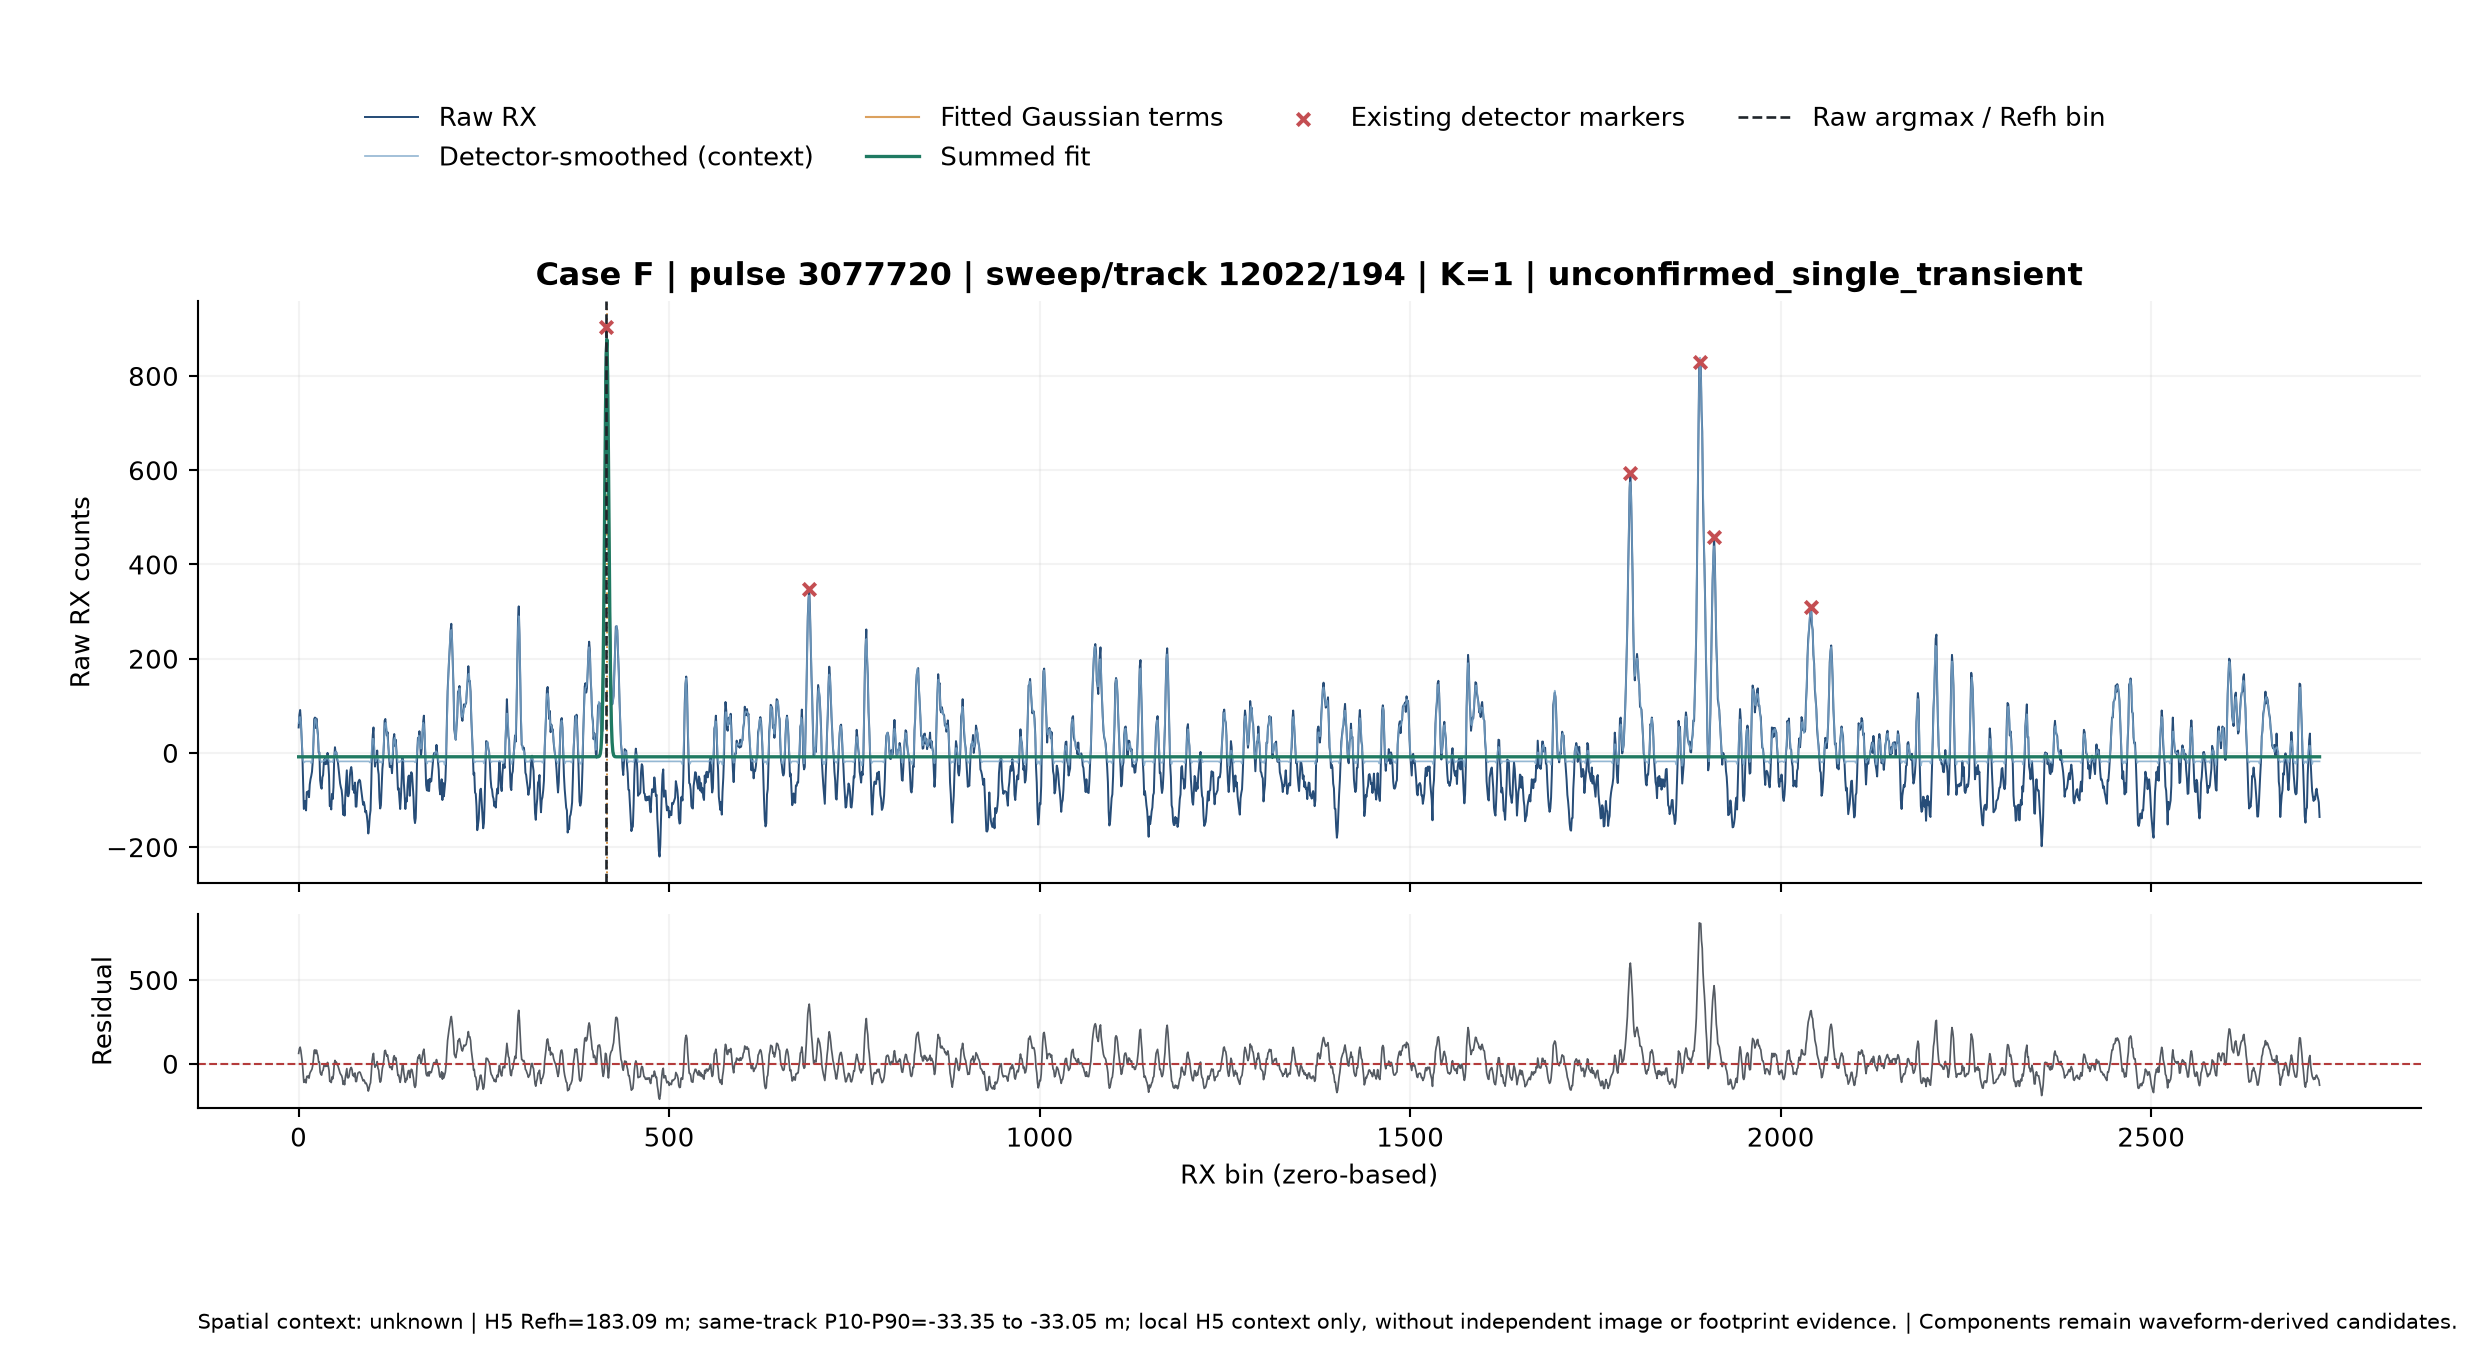

In [4]:
case_image_paths = []
for spec, result, arrays in zip(selected, case_results, wave_arrays):
    x = np.arange(arrays["raw"].size)
    fig, (ax, residual_ax) = plt.subplots(2, 1, figsize=(13, 7.2), sharex=True,
                                         gridspec_kw={"height_ratios": [3, 1]}, constrained_layout=False)
    fig.subplots_adjust(left=0.08, right=0.98, bottom=0.19, top=0.78, hspace=0.08)
    ax.plot(x, arrays["raw"], color="#274d78", lw=0.75, label="Raw RX")
    ax.plot(x, arrays["smoothed"], color="#7ba6c9", lw=0.65, alpha=0.8, label="Detector-smoothed (context)")
    for component_number, component in enumerate(arrays["components"], start=1):
        term = arrays["baseline"] + component["amplitude"] * np.exp(
            -0.5 * ((x - component["center_bin"]) / component["sigma_bins"]) ** 2)
        ax.plot(x, term, color="#d28a36", lw=0.8, alpha=0.8,
                label="Fitted Gaussian terms" if component_number == 1 else None)
        ax.axvline(component["center_bin"], color="#d28a36", lw=0.7, ls=":")
    ax.plot(x, arrays["fit"], color="#1f7a62", lw=1.25, label="Summed fit")
    detector_bins = np.asarray([item["peak_bin"] for item in arrays["detector"]], dtype=float)
    if detector_bins.size:
        ax.scatter(detector_bins, arrays["raw"][detector_bins.astype(int)], s=22, marker="x",
                   c="#c44e52", label="Existing detector markers", zorder=4)
    ax.axvline(result["raw_argmax_bin"], color="#20252b", lw=1.0, ls="--", label="Raw argmax / Refh bin")
    ax.set_ylabel("Raw RX counts")
    case_status = result["screen_status"] if result["case"] == "F" else result["fit_status"]
    ax.set_title(f"Case {result['case']} | pulse {result['pulse_index']} | sweep/track {result['sweep_num']}/{result['track_num']} | "
                 f"K={result['chosen_k']} | {case_status}")
    ax.grid(alpha=0.15)
    residual_ax.plot(x, arrays["residual"], color="#555b63", lw=0.65)
    residual_ax.axhline(0, color="#b43b3b", lw=0.8, ls="--")
    residual_ax.set(xlabel="RX bin (zero-based)", ylabel="Residual")
    residual_ax.grid(alpha=0.15)
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncol=4, frameon=False)
    context = result["spatial_evidence"]
    fig.text(0.08, 0.025, f"Spatial context: {result['land_cover']} | {context[:170]} | Components remain waveform-derived candidates.",
             ha="left", va="bottom", fontsize=8.0, wrap=True)
    path = OUTPUT_DIR / f"decomposition_case_{result['case']}.png"
    fig.savefig(path, dpi=DPI)
    plt.close(fig)
    case_image_paths.append(path)

# Display the unconfirmed screening case explicitly when available.
screen_path = case_image_paths[-1]
display(Image(filename=str(screen_path)))

## Figure 08-B | Meeting gallery board

The board compares a probable multi-component canopy-context waveform, a single-dominant canopy-context waveform, probable open-field and road/mixed-verge examples, a low-SNR case, and the independent early-transient screen. Spatial labels come from the prior local imagery review and remain probable; waveform shape does not assign land cover.

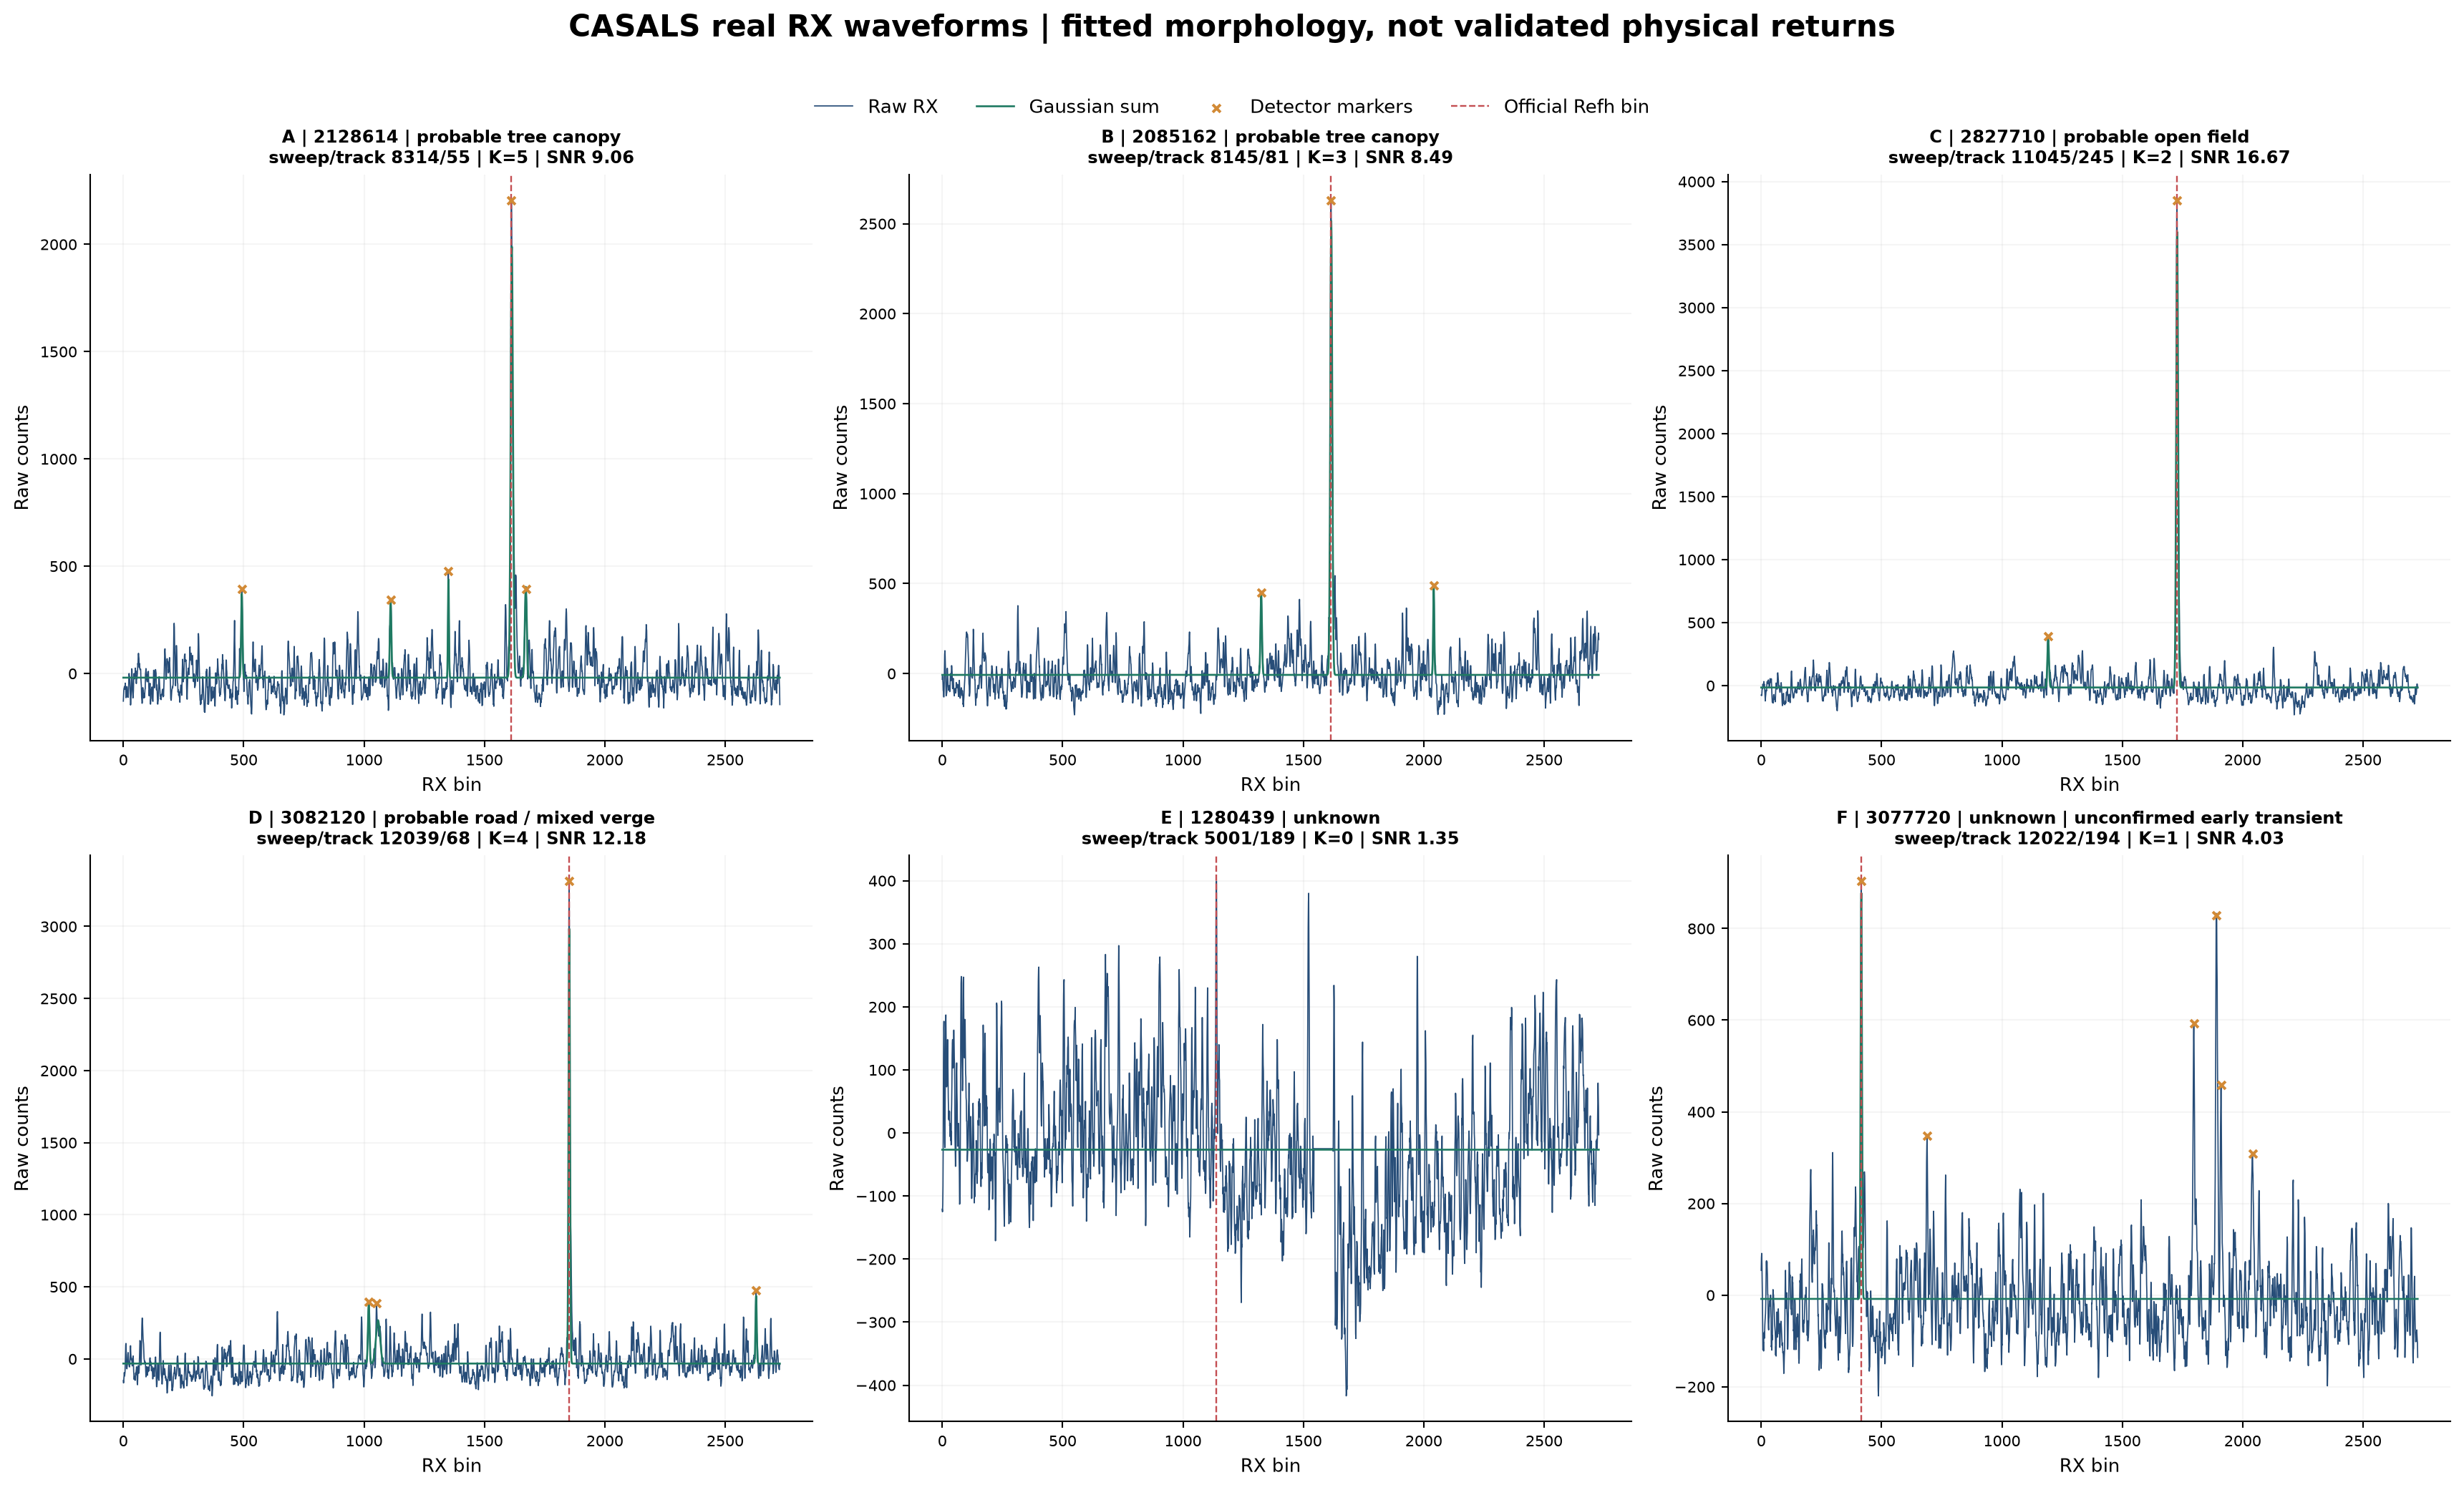

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
for ax, result, arrays in zip(axes.flat, case_results, wave_arrays):
    x = np.arange(arrays["raw"].size)
    ax.plot(x, arrays["raw"], color="#274d78", lw=0.65, label="Raw RX")
    ax.plot(x, arrays["fit"], color="#1f7a62", lw=1.0, label="Gaussian sum")
    detector_bins = np.asarray([item["peak_bin"] for item in arrays["detector"]], dtype=float)
    if detector_bins.size:
        ax.scatter(detector_bins, arrays["raw"][detector_bins.astype(int)], marker="x", s=17,
                   c="#d28a36", label="Detector markers", zorder=4)
    ax.axvline(result["official_refh_associated_bin"], color="#c44e52", ls="--", lw=0.9,
               label="Official Refh bin")
    screen_note = " | unconfirmed early transient" if str(result["screen_status"]).startswith("unconfirmed") else ""
    ax.set_title(f"{result['case']} | {result['pulse_index']} | {result['land_cover']}{screen_note}\n"
                 f"sweep/track {result['sweep_num']}/{result['track_num']} | K={result['chosen_k']} | SNR {result['snr']:.2f}", fontsize=9)
    ax.set_xlabel("RX bin"); ax.set_ylabel("Raw counts"); ax.grid(alpha=0.12)
    ax.tick_params(labelsize=8)
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.03), ncol=4, frameon=False)
fig.suptitle("CASALS real RX waveforms | fitted morphology, not validated physical returns", fontsize=16, fontweight="bold", y=1.08)
fig.savefig(OUTPUT_DIR / "waveform_decomposition_gallery.png", dpi=DPI, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / "waveform_decomposition_gallery.png")))

## Figure 08-C | Fit quality and model-order limits

K distribution, per-case raw-count RMSE and fitted FWHM summarize only these illustrative cases. A small or zero BIC margin, failed fit, no detected component or low SNR is reported as instability/ambiguity, not hidden by adding components.

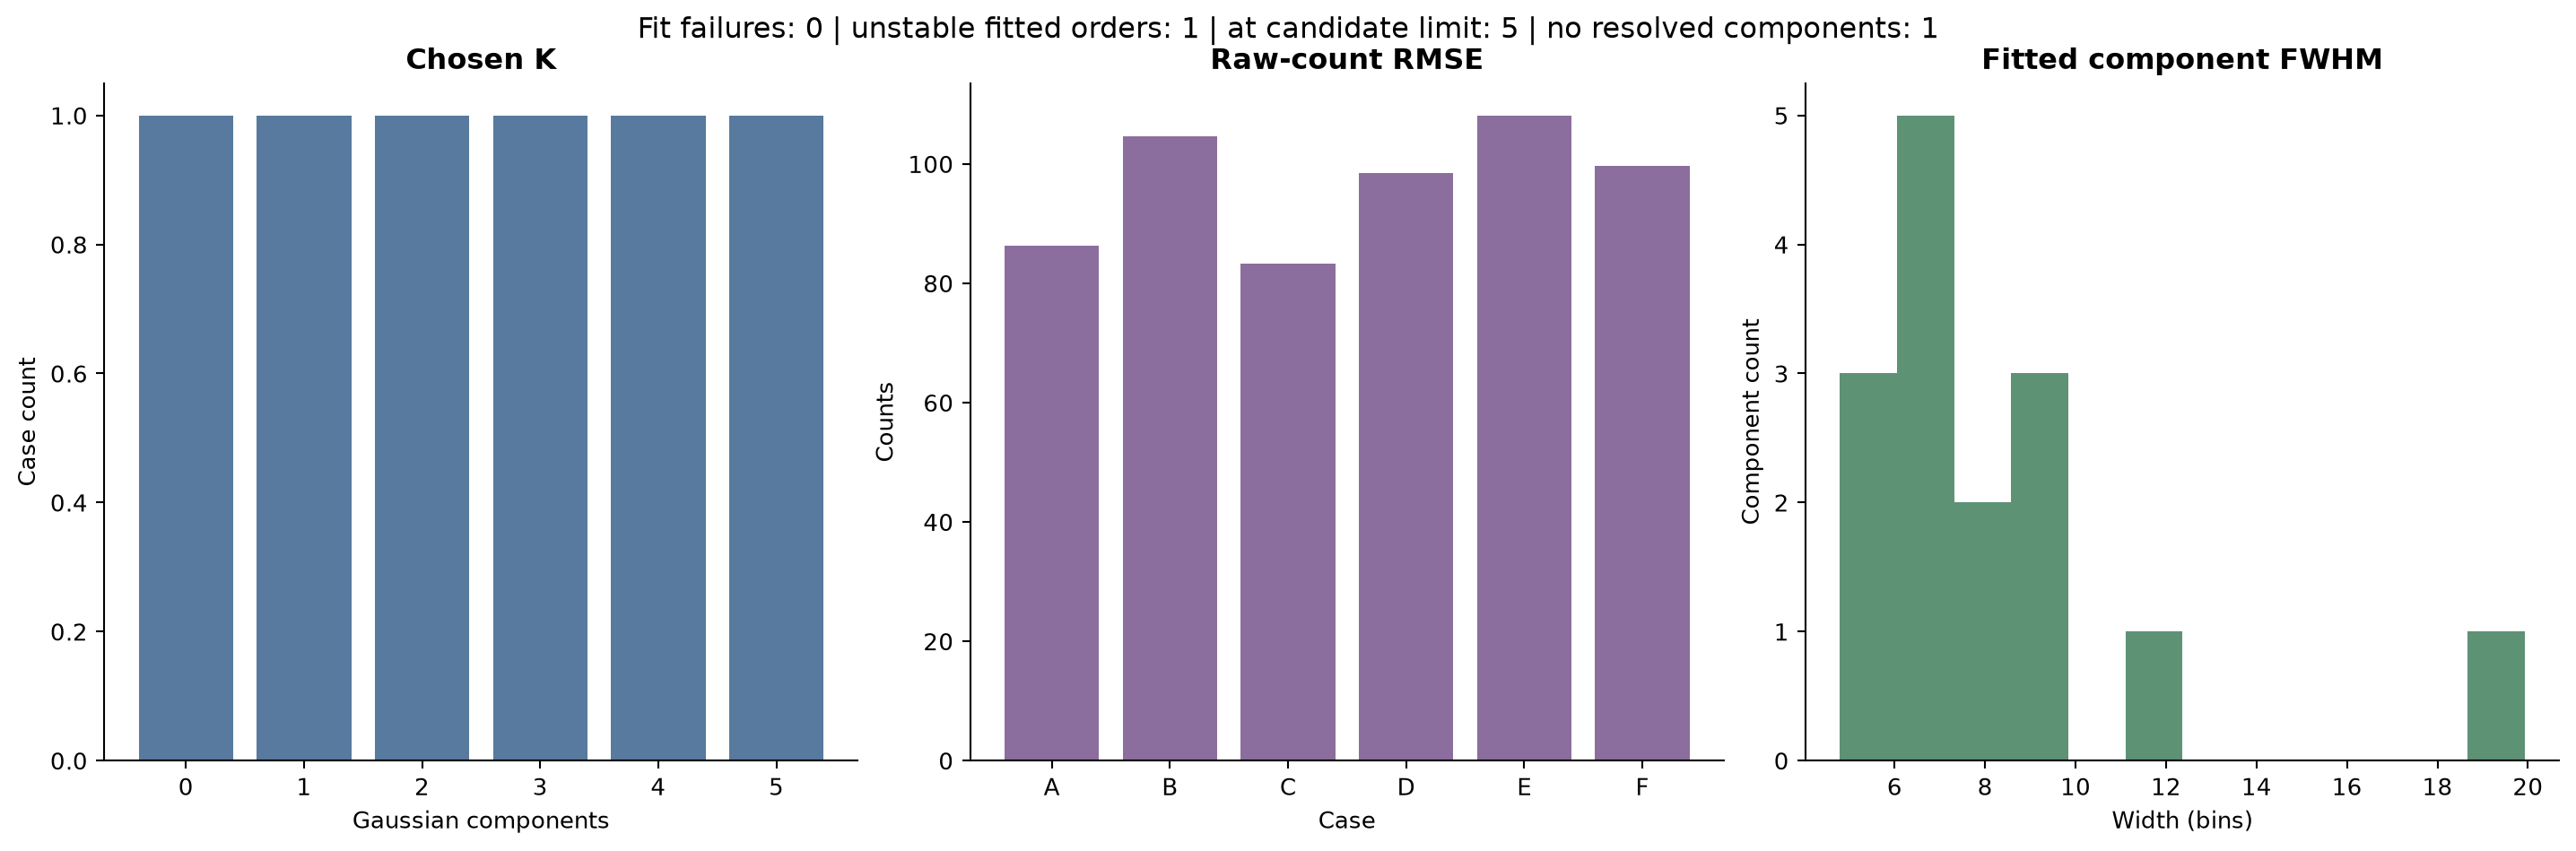

In [6]:
metrics = pd.DataFrame([{
    "case": row["case"], "pulse_index": row["pulse_index"], "sweep_num": row["sweep_num"],
    "track_num": row["track_num"], "snr": row["snr"], "chosen_k": row["chosen_k"],
    "fit_status": row["fit_status"], "fit_success": row["fit_success"],
    "bic": row["bic"], "delta_bic": row["delta_bic"], "stable_order": row["stable_order"],
    "at_search_limit": row["at_search_limit"], "fit_component_cap": row["fit_component_cap"],
    "rmse_counts": row["rmse_counts"], "noise_sigma": row["noise_sigma"],
    "max_component_snr": max([c["amplitude"] / max(row["noise_sigma"], 1e-9) for c in row["components"]], default=0.0),
} for row in case_results])
widths = [component["fwhm_bins"] for row in case_results for component in row["components"]]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.7), constrained_layout=True)
k_counts = metrics.chosen_k.value_counts().sort_index()
axes[0].bar(k_counts.index.astype(str), k_counts.values, color="#577a9e")
axes[0].set(title="Chosen K", xlabel="Gaussian components", ylabel="Case count")
axes[1].bar(metrics.case, metrics.rmse_counts, color="#8b6e9d")
axes[1].set(title="Raw-count RMSE", xlabel="Case", ylabel="Counts")
axes[1].tick_params(axis="x", rotation=0)
if widths:
    axes[2].hist(widths, bins=min(12, max(4, len(widths))), color="#5d9275")
axes[2].set(title="Fitted component FWHM", xlabel="Width (bins)", ylabel="Component count")
unstable_fit_count = int((metrics.fit_success & (metrics.chosen_k > 0) & ~metrics.stable_order).sum())
summary_note = f"Fit failures: {(~metrics.fit_success).sum()} | unstable fitted orders: {unstable_fit_count} | at candidate limit: {metrics.at_search_limit.sum()} | no resolved components: {(metrics.chosen_k == 0).sum()}"
fig.suptitle(summary_note, fontsize=12, y=1.03)
fig.savefig(OUTPUT_DIR / "waveform_fit_quality_summary.png", dpi=DPI, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / "waveform_fit_quality_summary.png")))

## Reproducibility record and interpretation

The chosen K values are descriptive and limited to these six pulses. A component center or width is not a range-corrected position. The screen case demonstrates an isolated early waveform transient only when Notebook 09 reports one; if Notebook 09 found no candidate band, this pulse remains explicitly unconfirmed. Under the evidence produced in that case, the decomposition is most appropriate for morphology understanding and candidate refinement, not direct physical interpretation.

In [7]:
examples_rows = []
for row in case_results:
    if row["components"]:
        for component_number, component in enumerate(row["components"], start=1):
            examples_rows.append({"case": row["case"], "pulse_index": row["pulse_index"],
                                  "sweep_num": row["sweep_num"], "track_num": row["track_num"],
                                  "component_index": component_number, "component_present": True,
                                  **component, "land_cover": row["land_cover"],
                                  "screen_status": row["screen_status"]})
    else:
        examples_rows.append({"case": row["case"], "pulse_index": row["pulse_index"],
                              "sweep_num": row["sweep_num"], "track_num": row["track_num"],
                              "component_index": 0, "component_present": False,
                              "center_bin": np.nan, "amplitude": np.nan, "sigma_bins": np.nan,
                              "fwhm_bins": np.nan, "land_cover": row["land_cover"],
                              "screen_status": row["screen_status"]})
examples = pd.DataFrame(examples_rows)
examples.to_csv(OUTPUT_DIR / "waveform_decomposition_examples.csv", index=False)
metrics.to_csv(OUTPUT_DIR / "waveform_fit_metrics.csv", index=False)

reflection_summary_path = ROOT / "outputs/notebooks/09_nadir_window_reflection" / H5_PATH.stem / "window_reflection_summary.json"
reflection_summary = json.loads(reflection_summary_path.read_text(encoding="utf-8")) if reflection_summary_path.is_file() else None
reflection_count = int(reflection_summary.get("finding", {}).get("candidate_band_count", 0)) if reflection_summary else None


def json_safe(value):
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating, float)):
        return float(value) if np.isfinite(value) else None
    if isinstance(value, (np.bool_,)):
        return bool(value)
    return value

cases_document = {
    "h5": str(H5_PATH.relative_to(ROOT)), "source_start_utc": source_attrs.get("start_utca"),
    "rx_record_axis": int(rx_axis), "n_rx_bins": int(rx.shape[1]),
    "selection": "Four Notebook 06 spatial-context cases, one low-SNR case, and one Notebook 09 screen pulse or real-data fallback.",
    "detector_config_source": detector_config_source, "detector_config": detector_config,
    "reflection_screen_candidate_band_count": reflection_count,
    "cases": case_results,
    "scientific_limits": [
        "Gaussian components are waveform-derived representations, not verified physical returns.",
        "The official Refh-associated bin remains the raw maximum-RX bin for each pulse.",
        "The Notebook 09 screening pulse is unconfirmed unless a recurring candidate band is reported; a single transient is insufficient.",
        "Spatial labels are probable historical-imagery context and are not inferred from waveform morphology.",
    ],
}
(OUTPUT_DIR / "waveform_decomposition_cases.json").write_text(
    json.dumps(json_safe(cases_document), indent=2, allow_nan=False), encoding="utf-8")

summary = {
    "h5": str(H5_PATH.relative_to(ROOT)), "n_cases": len(case_results),
    "chosen_k_distribution": {str(int(key)): int(value) for key, value in metrics.chosen_k.value_counts().sort_index().items()},
    "fit_failure_count": int((~metrics.fit_success).sum()),
    "unstable_order_count": int((metrics.fit_success & (metrics.chosen_k > 0) & ~metrics.stable_order).sum()),
    "at_candidate_limit_count": int(metrics.at_search_limit.sum()),
    "no_resolved_component_count": int((metrics.chosen_k == 0).sum()),
    "median_rmse_counts": float(metrics.rmse_counts.median()),
    "reflection_candidate_band_count_from_notebook09": reflection_count,
    "candidate_band_review_case_present": bool(reflection_count and any(r["screen_status"] == "candidate_band_requires_review" for r in case_results)),
    "interpretation_scope": "Waveform morphology and candidate refinement; no physical-return validation.",
    "meeting_use": "Gallery is suitable for a waveform-morphology discussion when the unconfirmed screen status and physical-return limits remain visible; it does not demonstrate a confirmed nadir-window signature.",
    "outputs": ["waveform_decomposition_gallery.png", "waveform_fit_quality_summary.png",
                "waveform_decomposition_examples.csv", "waveform_fit_metrics.csv",
                "waveform_decomposition_cases.json"],
}
(OUTPUT_DIR / "waveform_decomposition_summary.json").write_text(
    json.dumps(json_safe(summary), indent=2, allow_nan=False), encoding="utf-8")
print(json.dumps(summary, indent=2))
display(examples.head(18))

{
  "h5": "data\\raw\\casals_l1b\\casals_l1b_20241118T171757_001_02.h5",
  "n_cases": 6,
  "chosen_k_distribution": {
    "0": 1,
    "1": 1,
    "2": 1,
    "3": 1,
    "4": 1,
    "5": 1
  },
  "fit_failure_count": 0,
  "unstable_order_count": 1,
  "at_candidate_limit_count": 5,
  "no_resolved_component_count": 1,
  "median_rmse_counts": 99.03674399681822,
  "reflection_candidate_band_count_from_notebook09": 0,
  "candidate_band_review_case_present": false,
  "interpretation_scope": "Waveform morphology and candidate refinement; no physical-return validation.",
  "meeting_use": "Gallery is suitable for a waveform-morphology discussion when the unconfirmed screen status and physical-return limits remain visible; it does not demonstrate a confirmed nadir-window signature.",
  "outputs": [
    "waveform_decomposition_gallery.png",
    "waveform_fit_quality_summary.png",
    "waveform_decomposition_examples.csv",
    "waveform_fit_metrics.csv",
    "waveform_decomposition_cases.json"
  ]

,case,pulse_index,sweep_num,track_num,component_index,component_present,center_bin,amplitude,sigma_bins,fwhm_bins,land_cover,screen_status
0,A,2128614,8314,55,1,True,492.141486,391.226745,2.797591,6.587823,probable tree canopy,not_a_reflection_screen_case
1,A,2128614,8314,55,2,True,1110.376124,353.520231,3.105820,7.313646,probable tree canopy,not_a_reflection_screen_case
2,A,2128614,8314,55,3,True,1350.521727,470.347040,2.034264,4.790326,probable tree canopy,not_a_reflection_screen_case
3,A,2128614,8314,55,4,True,1613.809137,2010.096458,4.771225,11.235376,probable tree canopy,not_a_reflection_screen_case
4,A,2128614,8314,55,5,True,1671.886742,423.360228,4.048143,9.532648,probable tree canopy,not_a_reflection_screen_case
5,B,2085162,8145,81,1,True,1324.880361,451.197008,3.100992,7.302278,probable tree canopy,not_a_reflection_screen_case
6,B,2085162,8145,81,2,True,1615.921113,2522.710643,4.123602,9.710340,probable tree canopy,not_a_reflection_screen_case
7,B,2085162,8145,81,3,True,2041.540317,487.351982,2.339774,5.509746,probable tree canopy,not_a_reflection_screen_case
8,C,2827710,11045,245,1,True,1192.105721,378.331813,3.386448,7.974475,probable open field,not_a_reflection_screen_case
9,C,2827710,11045,245,2,True,1727.826845,3617.812143,3.934524,9.265097,probable open field,not_a_reflection_screen_case
